In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.1 MB/s eta 0:00:00


In [ ]:
!unzip -q /content/dataset.zip -d /content/dataset

In [ ]:
from ultralytics import YOLO

# Use a slightly larger model
model = YOLO('yolov8s.pt')  # Switch to 'yolov8n.pt'

model.train(
    data='/content/dataset/data.yaml',   # Path to dataset config file in YOLO format
    epochs=100,                          # Increased number of training epochs
    imgsz=416,                           # Lower image resolution (640→416)
    batch=-1,                             # Batch size
    workers=4,                           # Number of dataloader workers
    freeze=10,                           # Freeze the first 10 layers (typically the backbone); only train detection head
    name='yolo_head_tuned_v1',           # Name of this training run
    project='/content/runs/train',       # Output directory for training logs and weights
    pretrained=True,                     # Use pretrained COCO weights
    amp=True,

    # Enable data augmentation for better generalization
    mosaic=1.0,                          # Enable mosaic augmentation
    hsv_h=0.015,                         # Hue augmentation
    hsv_s=0.7,                           # Saturation augmentation
    hsv_v=0.4,                           # Value augmentation
    flipud=0.5,                          # Random vertical flip
    erasing=0.4,                         # Random erasing

    # Optional: Set initial learning rate
    lr0=0.01
)

Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_head_tuned_v13, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
AutoBatch: Computing optimal batch size for imgsz=416 at 60.0% CUDA memory utilization.
AutoBatch: CUDA:0 (Tesla T4) 14.74G total, 0.70G reserved, 0.66G allocated, 13.38G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output


    11137922       12.11         1.388         21.01         55.37        (1, 3, 416, 416)                    list
    11137922       24.22         1.416          24.1         59.44        (2, 3, 416, 416)                    list
    11137922       48.43         1.418         19.91         54.79        (4, 3, 416, 416)                    list
    11137922       96.86         1.420         27.17         52.52        (8, 3, 416, 416)                    list
    11137922       193.7         2.110         48.29         58.06       (16, 3, 416, 416)                    list
AutoBatch: Using batch-size 144 for CUDA:0 9.34G/14.74G (63%) ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 406.8±182.5 MB/s, size: 17.4 KB)


train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]

...

                   all       2098      18916      0.567      0.467      0.502      0.346

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     51/100      14.3G      1.105     0.8742      1.175       2035        416: 100%|██████████| 51/51 [00:54<00:00,  1.06s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:14<00:00,  1.83s/it]


                   all       2098      18916      0.563      0.469      0.494      0.336

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     52/100      12.9G      1.134     0.8702      1.176       1454        416: 100%|██████████| 51/51 [00:55<00:00,  1.08s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  12%|█▎        | 1/8 [00:02<00:19,  2.82s/it]

WARNING ⚠️ CUDA OutOfMemoryError in TaskAlignedAssigner, using CPU


In [1]:
from ultralytics import YOLO

model = YOLO('/content/runs/train/yolo_head_tuned_v13/weights/last.pt')

model.train(
    resume=True
)


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=144, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/train/yolo_head_tuned_v13/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_head_tuned_v13, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3.5±1.9 MB/s, size: 15.5 KB)


val: Scanning /content/dataset/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2098/2098 [00:00<?, ?it/s]


Plotting labels to /content/runs/train/yolo_head_tuned_v13/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0011250000000000001), 63 bias(decay=0.0)
Resuming training /content/runs/train/yolo_head_tuned_v13/weights/last.pt from epoch 52 to 100 total epochs
Image sizes 416 train, 416 val
Using 2 dataloader workers
Logging results to /content/runs/train/yolo_head_tuned_v13
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

     62/100      13.3G      1.105     0.8276      1.158       2146        416: 100%|██████████| 51/51 [00:54<00:00,  1.06s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:14<00:00,  1.79s/it]

                   all       2098      18916      0.576      0.462      0.494      0.343



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     63/100      9.71G      1.094     0.8275      1.157       1569        416:  16%|█▌        | 8/51 [00:08<00:43,  1.01s/it]
Exception in thread Thread-10 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/multiprocessing/reductions.py", li

KeyboardInterrupt: 

In [3]:
from ultralytics import YOLO

# Load the checkpoint saved at epoch 60
model = YOLO('/content/runs/train/yolo_head_tuned_v13/weights/last.pt')

# Continue training with updated settings
model.train(
    resume=False,                      # Do NOT use resume mode (it will ignore new parameters)
    epochs=30,                         # Continue training up to epoch 90
    data='/content/dataset/data.yaml',
    imgsz=416,                         # Input image size
    batch=-1,                          # Auto batch size based on available GPU memory
    workers=4,                         # Number of dataloader workers
    name='yolo_head_tuned_v13_ft',    # Name of this fine-tuning run
    project='/content/runs/train',    # Folder to save logs and weights
    pretrained=False,                 # Do not load COCO pretrained weights (we're continuing from last.pt)
    optimizer='AdamW',                # Use AdamW optimizer (more stable than SGD in some cases)
    lr0=0.001,                        # Lower initial learning rate (was 0.01 before)
    freeze=0,                         # Unfreeze all layers to fine-tune the entire model (not just the head)

    # Reduce augmentation strength to improve stability during fine-tuning
    mosaic=0.5,                       # Lower mosaic augmentation probability
    erasing=0.2,                      # Lower random erasing probability
    patience=5,                       # If there is no improvement in performance within 5 epochs, stop training early

    amp=True                          # Use Automatic Mixed Precision (faster & less GPU memory)
)


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/train/yolo_head_tuned_v13/weights/last.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=yolo_head_tuned_v13_ft2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pati

train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
AutoBatch: Computing optimal batch size for imgsz=416 at 60.0% CUDA memory utilization.
AutoBatch: CUDA:0 (Tesla T4) 14.74G total, 2.46G reserved, 0.37G allocated, 11.92G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output


    11137922       12.11         3.047         24.98         20.14        (1, 3, 416, 416)                    list
    11137922       24.22         3.091         23.08         22.87        (2, 3, 416, 416)                    list
    11137922       48.43         3.095         22.62         32.73        (4, 3, 416, 416)                    list
    11137922       96.86         3.093         28.37          50.2        (8, 3, 416, 416)                    list
    11137922       193.7         4.001         43.88         68.25       (16, 3, 416, 416)                    list
AutoBatch: Using batch-size 61 for CUDA:0 9.77G/14.74G (66%) ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 724.1±171.3 MB/s, size: 17.4 KB)


train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]

...

      30/30      10.5G      1.061       0.73      1.137         19        416: 100%|██████████| 121/121 [01:02<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:13<00:00,  1.33it/s]


                   all       2098      18916      0.607      0.479      0.549      0.383

30 epochs completed in 0.656 hours.
Optimizer stripped from /content/runs/train/yolo_head_tuned_v13_ft2/weights/last.pt, 22.5MB
Optimizer stripped from /content/runs/train/yolo_head_tuned_v13_ft2/weights/best.pt, 22.5MB

Validating /content/runs/train/yolo_head_tuned_v13_ft2/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:18<00:00,  1.04s/it]


                   all       2098      18916      0.629      0.462      0.554      0.387
         BIODEGRADABLE        676      13637      0.876       0.41      0.628      0.358
             CARDBOARD        438       1292      0.737      0.521       0.63      0.483
                 GLASS        805       2380      0.892      0.694      0.818       0.62
                 METAL        398       1360      0.819      0.544        0.7      0.476
                 PAPER         15         33     0.0539     0.0606     0.0632     0.0587
               PLASTIC         91        214      0.396      0.542      0.486      0.327
Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/train/yolo_head_tuned_v13_ft2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aba20173510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [5]:
# Load the best trained model
model = YOLO('/content/runs/train/yolo_head_tuned_v13_ft2/weights/best.pt')

# Perform evaluation on the test set with Test-Time Augmentation (TTA) enabled
metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    augment=True,
    project='runs/detect',
    name='head_tuned_test_eval'
)

# Print key evaluation metrics
print("mAP50:", metrics.box.map50)         # Mean Average Precision at IoU threshold 0.5
print("mAP50-95:", metrics.box.map)        # Mean Average Precision averaged over IoU thresholds from 0.5 to 0.95
print("Precision (mean):", metrics.box.mp) # Mean precision across all classes
print("Recall (mean):", metrics.box.mr)    # Mean recall across all classes
print("Per-class AP@50:", metrics.box.ap50)   # AP@0.5 for each class
print("Per-class AP@50-95:", metrics.box.ap)  # AP@0.5–0.95 for each class



Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 70.6±143.6 MB/s, size: 26.8 KB)


val: Scanning /content/dataset/test/labels... 1042 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1042/1042 [00:00<00:00, 1518.51it/s]


val: New cache created: /content/dataset/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 66/66 [00:16<00:00,  3.99it/s]


                   all       1042       3563      0.501      0.463      0.451      0.349
         BIODEGRADABLE          8         49      0.152      0.163     0.0921     0.0481
             CARDBOARD         11         20     0.0818       0.35      0.127      0.116
                 METAL        172        533      0.772      0.668       0.69      0.585
                 PAPER        515       1376      0.798      0.509      0.641      0.505
               PLASTIC        354       1585      0.701      0.623      0.705      0.493
Speed: 0.4ms preprocess, 10.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/head_tuned_test_eval
mAP50: 0.4509059516158532
mAP50-95: 0.3493829504935659
Precision (mean): 0.5011620260586046
Recall (mean): 0.4625708534301416
Per-class AP@50: [   0.092065     0.12686     0.69007     0.64082     0.70472]
Per-class AP@50-95: [   0.048109     0.11589     0.58496     0.50453     0.49342]


In [6]:
from google.colab import files
files.download('/content/runs/train/yolo_head_tuned_v13_ft2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

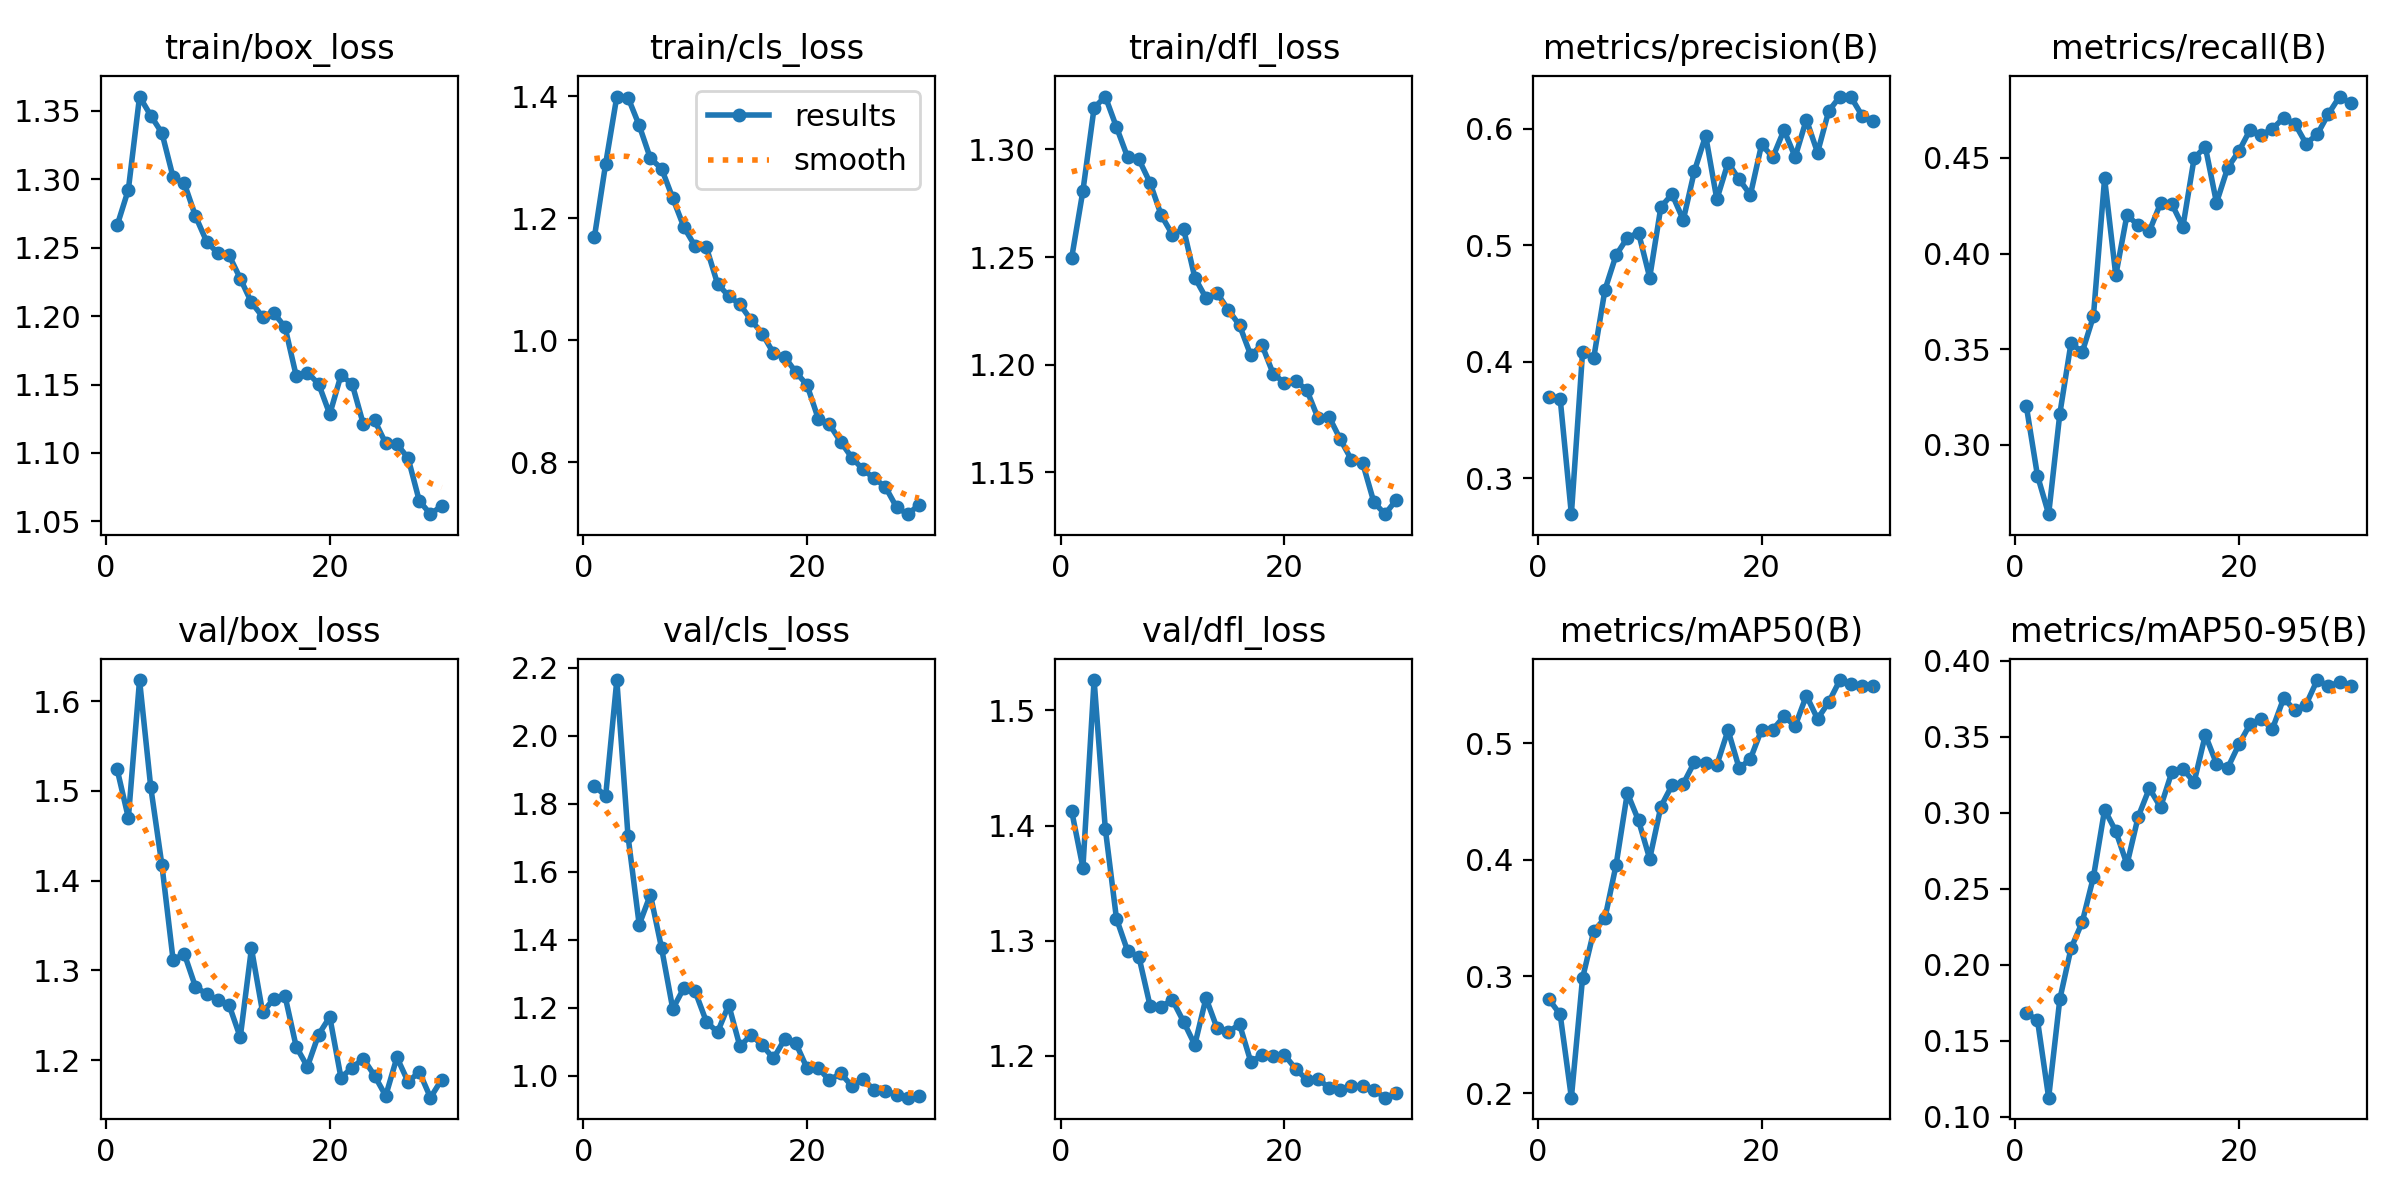

In [8]:
import pandas as pd
from IPython.display import Image

# Load training metrics
df = pd.read_csv('/content/runs/train/yolo_head_tuned_v13_ft2/results.csv')
df.tail()

# Plot training curves (loss, mAP)
Image(filename='/content/runs/train/yolo_head_tuned_v13_ft2/results.png')


0: 416x416 1 CARDBOARD, 1 METAL, 8.8ms
1: 416x416 1 GLASS, 1 METAL, 8.8ms
2: 416x416 2 METALs, 8.8ms
3: 416x416 1 METAL, 8.8ms
4: 416x416 2 METALs, 8.8ms
Speed: 1.0ms preprocess, 8.8ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict_metal


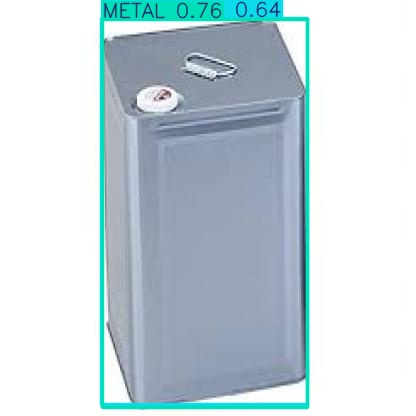

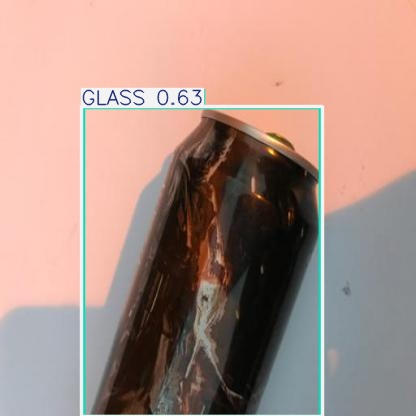

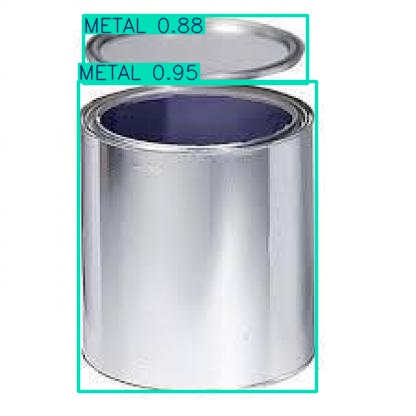

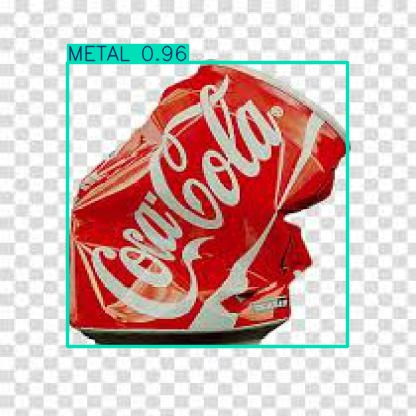

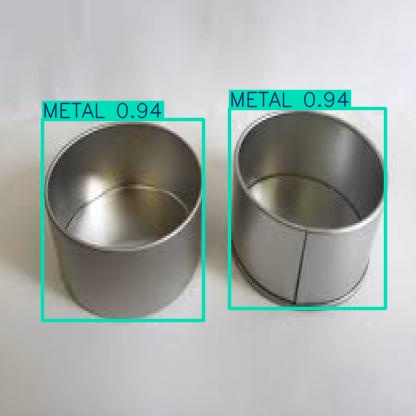

In [9]:
from ultralytics import YOLO
from IPython.display import display, Image

# Load the trained YOLOv8 model
model = YOLO('/content/runs/train/yolo_head_tuned_v13_ft2/weights/best.pt')

# List of 5 test image paths to perform inference on
image_paths = [
    '/content/dataset/test/images/metal1000_jpg.rf.f972491130c59d3bff7e97b22e8e2980.jpg',
    '/content/dataset/test/images/metal1005_jpg.rf.d736ab336e8fa92ce57727666e624259.jpg',
    '/content/dataset/test/images/metal100_jpg.rf.8605f3d87c15f6f37575fa2907d5bc6c.jpg',
    '/content/dataset/test/images/metal1014_jpeg.rf.7c66a5a281d17fde9891d5777c496391.jpg',
    '/content/dataset/test/images/metal1016_jpg.rf.e9045ffa8d93980005dca0adcce9f187.jpg'
]

# Run inference and save predictions to the 'predict_metal' folder
results = model.predict(
    source=image_paths,          # Input images
    save=True,                   # Save annotated predictions
    project='runs/detect',       # Root directory for saving results
    name='predict_metal',        # Subfolder name
    conf=0.25                    # Confidence threshold
)

# Display the prediction results inline
for img_path in image_paths:
    filename = img_path.split('/')[-1]
    result_path = f'/content/runs/detect/predict_metal/{filename}'
    display(Image(filename=result_path))
